## 1. ¿Qué es una CNN y por qué se utiliza en imágenes?

Una **Red Neuronal Convolucional (CNN, Convolutional Neural Network)** es un tipo de red neuronal diseñada especialmente para trabajar con datos que presentan una estructura espacial, como las imágenes.

En una imagen, los píxeles cercanos están relacionados entre sí y pueden formar patrones como bordes, texturas, formas y estructuras. Las CNN aprovechan esta característica mediante operaciones de **convolución**, que permiten detectar automáticamente diferentes características de la imagen.

En las primeras capas, la red puede aprender patrones simples, como bordes y cambios de intensidad o color. Conforme aumenta la profundidad de la red, las características aprendidas se vuelven más complejas y pueden representar formas, texturas y estructuras presentes en la imagen.

### 1.1. Componentes principales de una CNN

**a) Convolución (Conv2D)**

La capa convolucional aplica filtros o kernels que recorren la imagen para detectar diferentes características. Cada filtro aprende automáticamente los patrones que resultan útiles para la tarea de clasificación.

**b) Función de activación (ReLU)**

La función ReLU introduce no linealidad en la red y se define como:

\[
ReLU(x)=\max(0,x)
\]

De esta manera, los valores negativos se convierten en cero y los positivos se mantienen.

**c) Pooling**

Las capas de pooling reducen las dimensiones espaciales de las características obtenidas por las convoluciones. En este trabajo se utiliza `MaxPool2d`, que conserva los valores máximos de pequeñas regiones de la imagen.

Esto permite reducir el costo computacional y conservar las características más relevantes.

**d) Clasificador**

Después de extraer características mediante las capas convolucionales, estas se utilizan para realizar la clasificación final. En este trabajo, la última capa produce dos valores correspondientes a las dos clases del problema.

### 1.2. ¿Por qué utilizar una CNN para la clasificación de lesiones cutáneas?

Las imágenes dermatoscópicas pueden presentar diferencias de color, textura, forma, bordes y otros patrones visuales. Una CNN permite aprender automáticamente representaciones de estas características a partir de las imágenes, sin tener que definir manualmente cada característica.

En este ejercicio se utiliza una CNN para realizar una **clasificación binaria**, diferenciando entre:

- **Clase 0:** no melanoma.
- **Clase 1:** melanoma.

Posteriormente también se utilizará **transfer learning**, mediante una red ResNet18 preentrenada, para aprovechar características aprendidas previamente en un conjunto de imágenes de gran tamaño.

## 2. Preparación del entorno

Para desarrollar el modelo de clasificación se utiliza **Python** junto con la biblioteca **PyTorch**, que permite construir, entrenar y evaluar redes neuronales.

También se utilizan otras bibliotecas para el procesamiento de imágenes, manipulación de datos, visualización y evaluación del modelo.

Las principales herramientas utilizadas son:

- **PyTorch:** construcción y entrenamiento de las redes neuronales.
- **Torchvision:** transformaciones de imágenes y modelos preentrenados.
- **Pandas:** lectura y manipulación de los datos de las etiquetas.
- **NumPy:** operaciones numéricas.
- **Matplotlib:** visualización de imágenes y resultados.
- **Pillow (PIL):** lectura de las imágenes JPEG.
- **Scikit-learn:** división de los datos y cálculo de métricas de clasificación.
- **tqdm:** visualización del progreso durante algunos procesos.

El entrenamiento se realiza utilizando GPU mediante CUDA cuando está disponible, con el objetivo de acelerar el procesamiento de las redes neuronales.


In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "pillow"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
import requests

url = "https://isic-archive.s3.amazonaws.com/challenges/2017/ISIC-2017_Training_Data.zip"

r = requests.head(url)

print("Estado:", r.status_code)
print("Tamaño:", r.headers.get("Content-Length"))

Estado: 200
Tamaño: 6229496702


In [63]:
import requests
from tqdm import tqdm

url = "https://isic-archive.s3.amazonaws.com/challenges/2017/ISIC-2017_Training_Data.zip"
output = "/content/ISIC-2017_Training_Data.zip"

response = requests.get(url, stream=True)
total_size = int(response.headers.get("content-length", 0))

with open(output, "wb") as f:
    with tqdm(total=total_size, unit="B", unit_scale=True, unit_divisor=1024) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

print(" Descarga terminada")

100%|██████████| 5.80G/5.80G [02:20<00:00, 44.4MB/s]

 Descarga terminada


In [ ]:
import pandas as pd

url_csv = "https://isic-archive.s3.amazonaws.com/challenges/2017/ISIC-2017_Training_Part3_GroundTruth.csv"

df = pd.read_csv(url_csv)

df.head()

,image_id,melanoma,seborrheic_keratosis
0,ISIC_0000000,0.0,0.0
1,ISIC_0000001,0.0,0.0
2,ISIC_0000002,1.0,0.0
3,ISIC_0000003,0.0,0.0
4,ISIC_0000004,1.0,0.0


In [ ]:
df.columns

Index(['image_id', 'melanoma', 'seborrheic_keratosis'], dtype='object')

In [ ]:
df.shape

(2000, 3)

In [ ]:
df["label"] = df["melanoma"].astype(int)

print(df["label"].value_counts())

label
0    1626
1     374
Name: count, dtype: int64


In [ ]:
print(df[["image_id", "melanoma", "label"]].head(10))

       image_id  melanoma  label
0  ISIC_0000000       0.0      0
1  ISIC_0000001       0.0      0
2  ISIC_0000002       1.0      1
3  ISIC_0000003       0.0      0
4  ISIC_0000004       1.0      1
5  ISIC_0000006       0.0      0
6  ISIC_0000007       0.0      0
7  ISIC_0000008       0.0      0
8  ISIC_0000009       0.0      0
9  ISIC_0000010       0.0      0


In [70]:
import zipfile
import os

zip_path = "/content/ISIC-2017_Training_Data.zip"
extract_path = "/content/ISIC_2017"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(" Archivos descomprimidos")

 Archivos descomprimidos


In [ ]:
import os

for root, dirs, files in os.walk("/content/ISIC_2017"):
    print(root, len(files))

/content/ISIC_2017 0
/content/ISIC_2017/ISIC-2017_Training_Data 4001


### 2.1. Importación de bibliotecas

Se importan las bibliotecas y funciones necesarias para cargar las imágenes, preparar los datos, construir las redes neuronales y evaluar sus resultados.

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## 3. Preparación y carga del dataset

Para este ejercicio se utiliza el conjunto de datos **ISIC 2017**, específicamente las imágenes correspondientes a la tarea de clasificación de lesiones cutáneas.

Las imágenes se encuentran en formato JPEG y presentan diferentes dimensiones. Por esta razón, posteriormente serán redimensionadas a un tamaño común antes de ingresar a la red neuronal.

El archivo de etiquetas contiene información sobre cada imagen y permite identificar si la lesión corresponde o no a melanoma.

Para convertir el problema en una clasificación binaria se utiliza la variable `melanoma`:

- **0:** no melanoma.
- **1:** melanoma.

De esta manera, la red neuronal tendrá únicamente dos clases de salida.

### 3.1. Lectura y preparación de las etiquetas

El archivo CSV contiene la identificación de cada imagen y las variables asociadas al diagnóstico de la lesión.

Se utiliza la columna `melanoma` como variable objetivo. Esta variable ya contiene valores binarios, donde 0 representa ausencia de melanoma y 1 representa melanoma.

Se crea una nueva columna denominada `label`, que será utilizada posteriormente por PyTorch como la etiqueta de clasificación.
### 3.2. División en entrenamiento, validación y prueba

Para evaluar el comportamiento del modelo de manera adecuada, el conjunto de datos se divide en tres subconjuntos:

- **Entrenamiento (train):** se utiliza para ajustar los parámetros de la red neuronal.
- **Validación (validation):** se utiliza durante el desarrollo para observar el comportamiento del modelo sobre datos que no participan directamente en el ajuste de sus pesos.
- **Prueba (test):** se utiliza al final para obtener una evaluación del modelo sobre datos que no fueron utilizados durante el entrenamiento.

La división se realiza mediante `train_test_split` utilizando `stratify`. Esto permite conservar aproximadamente la misma proporción de las clases 0 y 1 en los tres subconjuntos.

Se utiliza `random_state=42` para que la división sea reproducible.

In [ ]:
url_csv = "https://isic-archive.s3.amazonaws.com/challenges/2017/ISIC-2017_Training_Part3_GroundTruth.csv"

df = pd.read_csv(url_csv)

df.head()

,image_id,melanoma,seborrheic_keratosis
0,ISIC_0000000,0.0,0.0
1,ISIC_0000001,0.0,0.0
2,ISIC_0000002,1.0,0.0
3,ISIC_0000003,0.0,0.0
4,ISIC_0000004,1.0,0.0


In [ ]:
df["label"] = df["melanoma"].astype(int)

print(df["label"].value_counts())

label
0    1626
1     374
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1400
Validation: 300
Test: 300


Con esta división se obtienen:

- **1400 imágenes para entrenamiento**
- **300 imágenes para validación**
- **300 imágenes para prueba**

La división corresponde aproximadamente a 70 % para entrenamiento, 15 % para validación y 15 % para prueba.

In [ ]:
print("Ejemplos de etiquetas:")
print(train_df[["image_id", "label"]].head(10))   #COMPROBAMOSSS

print("\nCantidad de cada clase:")
print(train_df["label"].value_counts())

Ejemplos de etiquetas:
          image_id  label
1811  ISIC_0014545      1
1129  ISIC_0012329      0
634   ISIC_0009933      0
1764  ISIC_0014353      0
136   ISIC_0000150      1
444   ISIC_0000544      0
631   ISIC_0009930      0
1521  ISIC_0013552      0
162   ISIC_0000184      0
1901  ISIC_0014769      0

Cantidad de cada clase:
label
0    1138
1     262
Name: count, dtype: int64


La distribución de las etiquetas permite verificar cuántas imágenes pertenecen a cada clase antes de realizar la división de los datos. Esta revisión es importante porque permite identificar si existe un desbalance entre las clases.

### 3.3. Creación del Dataset personalizado

Como las imágenes de ISIC están almacenadas individualmente como archivos JPEG y las etiquetas se encuentran en un archivo CSV separado, se crea una clase personalizada llamada `MelanomaDataset`.

Esta clase hereda de `Dataset` de PyTorch y permite definir cómo se obtiene cada imagen y su correspondiente etiqueta.

El método `__len__()` devuelve el número de imágenes disponibles, mientras que `__getitem__()` permite acceder a una imagen específica mediante su índice.

Para cada elemento, se obtiene el `image_id` desde el DataFrame, se construye la ruta del archivo JPEG y se abre la imagen utilizando Pillow. Las imágenes se convierten a formato RGB para asegurar que tengan tres canales de color.

Finalmente, la etiqueta se convierte a un tensor de tipo `long`, que es el formato esperado por `CrossEntropyLoss`.

In [ ]:
transform_basic = T.Compose([
    T.ToTensor()
])

In [ ]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_id = self.dataframe.loc[idx, "image_id"]
        label = self.dataframe.loc[idx, "label"]

        image_path = os.path.join(
            self.image_dir,
            image_id + ".jpg"
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

### 3.4. Ubicación de las imágenes

Se define la ruta donde se encuentran las imágenes JPEG del conjunto de datos.

Esta ruta se utiliza posteriormente por `MelanomaDataset` para localizar cada imagen a partir de su `image_id`.

In [69]:
image_dir = "/content/ISIC_2017/ISIC-2017_Training_Data"

print(" Ruta de imágenes:", image_dir)
print(" Carpeta existe:", os.path.exists(image_dir))

 Ruta de imágenes: /content/ISIC_2017/ISIC-2017_Training_Data
 Carpeta existe: True


### 3.5. Transformaciones de las imágenes

Las imágenes originales del dataset presentan diferentes dimensiones. Sin embargo, una red neuronal convolucional necesita recibir imágenes con dimensiones compatibles dentro de cada batch.

Por esta razón, se utiliza `Resize((224, 224))` para convertir todas las imágenes a un tamaño común de 224 × 224 píxeles.

Posteriormente, `ToTensor()` convierte la imagen de formato PIL a un tensor de PyTorch y transforma los valores de los píxeles al intervalo [0, 1].

Las imágenes se mantienen en formato RGB, por lo que cada imagen tiene tres canales de entrada.

In [68]:
transform_basic = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

print(" Transformación básica creada")

 Transformación básica creada


### 3.6. Creación de los conjuntos de datos

A partir de los DataFrames obtenidos anteriormente se crean tres objetos `MelanomaDataset`: uno para entrenamiento, uno para validación y uno para prueba.

Los tres conjuntos utilizan inicialmente las mismas transformaciones básicas. En secciones posteriores se incorporarán transformaciones adicionales para realizar data augmentation sobre el conjunto de entrenamiento.

In [67]:
train_dataset = MelanomaDataset(
    train_df,
    image_dir,
    transform=transform_basic
)

val_dataset = MelanomaDataset(
    val_df,
    image_dir,
    transform=transform_basic
)

test_dataset = MelanomaDataset(
    test_df,
    image_dir,
    transform=transform_basic
)

print(" Datasets actualizados")

 Datasets actualizados


In [66]:
import requests

csv_url = "https://isic-archive.s3.amazonaws.com/challenges/2017/ISIC-2017_Training_Part3_GroundTruth.csv"
csv_path = "/content/ISIC-2017_Training_Part3_GroundTruth.csv"

response = requests.get(csv_url)

with open(csv_path, "wb") as f:
    f.write(response.content)

print(" CSV de etiquetas descargado")
print(csv_path)

 CSV de etiquetas descargado
/content/ISIC-2017_Training_Part3_GroundTruth.csv


In [ ]:
import pandas as pd

csv_path = "/content/ISIC-2017_Training_Part3_GroundTruth.csv"

df = pd.read_csv(csv_path)

df["label"] = df["melanoma"].astype(int)

print("Dataset:", df.shape)
print("\nCantidad de cada clase:")
print(df["label"].value_counts())

Dataset: (2000, 4)

Cantidad de cada clase:
label
0    1626
1     374
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1400
Validation: 300
Test: 300


In [65]:
image_dir = "/content/ISIC_2017/ISIC-2017_Training_Data"

train_dataset = MelanomaDataset(
    train_df,
    image_dir,
    transform=transform_basic
)

val_dataset = MelanomaDataset(
    val_df,
    image_dir,
    transform=transform_basic
)

test_dataset = MelanomaDataset(
    test_df,
    image_dir,
    transform=transform_basic
)

print(" Datasets creados")

 Datasets creados


In [ ]:
batch_size = 128

print("batch_size =", batch_size)

batch_size = 128


In [64]:

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(" DataLoaders actualizados")

 DataLoaders actualizados


In [ ]:
x, y = next(iter(train_loader))

print("Forma de las imágenes:", x.shape)
print("Forma de las etiquetas:", y.shape)

Forma de las imágenes: torch.Size([128, 3, 224, 224])
Forma de las etiquetas: torch.Size([128])


### 3.7. Visualización de ejemplos

Antes de comenzar el entrenamiento, se visualizan algunas imágenes del conjunto de entrenamiento para comprobar que las imágenes se cargan correctamente y que las etiquetas están asociadas a cada muestra.

Como las imágenes son RGB, se reorganizan sus dimensiones de `(canales, alto, ancho)` a `(alto, ancho, canales)` antes de mostrarlas con Matplotlib.

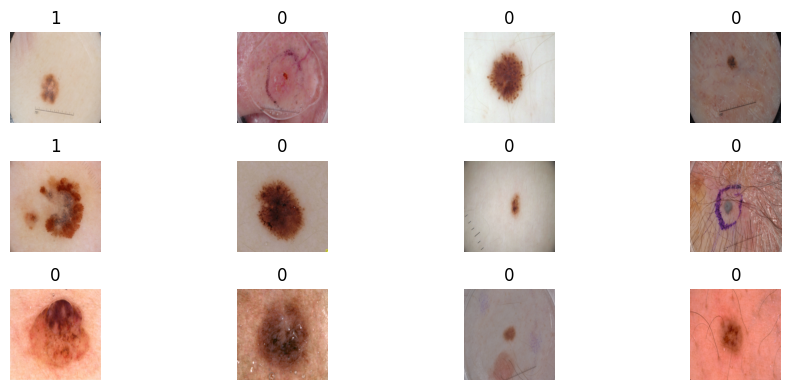

In [ ]:
def show_batch(dataset, n=12):

    plt.figure(figsize=(10, 4))

    for i in range(n):

        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)

        # Convertir de [C, H, W] a [H, W, C]
        img = x.permute(1, 2, 0)

        plt.imshow(img)

        plt.title(int(y))
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_batch(train_dataset, n=12)

Las imágenes se muestran junto con su etiqueta correspondiente. La etiqueta `0` representa ausencia de melanoma y la etiqueta `1` representa melanoma.

Esta visualización permite comprobar que el proceso de carga y transformación de las imágenes funciona correctamente antes de iniciar el entrenamiento.

## 4. Configuración del entorno de ejecución

En esta sección se prepara el entorno que se utilizará posteriormente para cargar los datos y entrenar la red neuronal.

Primero se importa `DataLoader` de PyTorch, una herramienta que permite organizar posteriormente las imágenes del dataset en lotes para su procesamiento.

También se selecciona el dispositivo de procesamiento. PyTorch verifica si existe una GPU compatible con CUDA mediante `torch.cuda.is_available()`. Si está disponible, se utiliza la GPU (`cuda`) para acelerar los cálculos; de lo contrario, se utiliza la CPU (`cpu`).

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
from torch.utils.data import DataLoader

print("DataLoader está cargado correctamente")

DataLoader está cargado correctamente


## 5. Modelo 1: CNN entrenada desde cero

En esta sección se construye una red neuronal convolucional (CNN) desde cero para clasificar imágenes dermatoscópicas del dataset ISIC 2017 en dos clases:

* **Clase 0:** no melanoma.
* **Clase 1:** melanoma.

La red está formada por capas convolucionales para extraer características de las imágenes, capas de activación ReLU y operaciones de MaxPooling para reducir progresivamente las dimensiones espaciales.

Se incorpora una capa **Dropout** antes de la clasificación final como técnica de regularización. Esta capa desactiva aleatoriamente una proporción de las neuronas durante el entrenamiento, ayudando a reducir el sobreajuste.





### 5.1 Arquitectura de la CNN con Dropout

Se construye una red neuronal convolucional (CNN) desde cero para clasificar las imágenes dermatoscópicas del dataset ISIC 2017 en dos clases:

* **Clase 0:** no melanoma.
* **Clase 1:** melanoma.

La arquitectura utiliza capas convolucionales para extraer características de las imágenes, funciones de activación **ReLU** y capas **MaxPooling** para reducir progresivamente las dimensiones espaciales.

Como estrategia de regularización, se incorpora una capa **Dropout con una tasa de 0.3** antes de la capa de clasificación. Durante el entrenamiento, Dropout desactiva aleatoriamente el 30 % de las activaciones de esa capa en cada iteración. Esto ayuda a reducir la dependencia excesiva entre neuronas y puede disminuir el riesgo de sobreajuste.

La clasificación final se realiza mediante una capa lineal que produce dos valores, correspondientes a las dos clases del problema.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = 2

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)

### 5.2 Funciones de entrenamiento y evaluación

Se definen funciones para entrenar el modelo y evaluar su desempeño mediante accuracy y ROC-AUC. También se calcula la pérdida de validación para poder comparar el comportamiento del modelo durante el entrenamiento.



In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return acc, auc, y_true, y_pred, y_prob


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

In [ ]:
@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        logits = model(x)
        loss = criterion(logits, y)

        losses.append(loss.item())

    return float(np.mean(losses))

### 5.3 Entrenamiento de la CNN

La CNN se entrena utilizando la función de pérdida CrossEntropyLoss y el optimizador Adam. Se utilizan 12 épocas para observar la evolución de las pérdidas y métricas durante el entrenamiento.

Se registran la pérdida de entrenamiento, la pérdida de validación, la accuracy y el ROC-AUC de validación para analizar el comportamiento del modelo y detectar posibles signos de sobreajuste.


In [38]:
model_scratch = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

epochs = 12

history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    val_loss = evaluate_loss(
        model_scratch,
        val_loader,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_scratch,
        val_loader
    )

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5807 | val_loss=0.4426 | val_acc=0.8133 | val_auc=0.5968
Epoch 02 | train_loss=0.4923 | val_loss=0.4454 | val_acc=0.8133 | val_auc=0.6002
Epoch 03 | train_loss=0.4847 | val_loss=0.4435 | val_acc=0.8133 | val_auc=0.6053
Epoch 04 | train_loss=0.4787 | val_loss=0.4416 | val_acc=0.8133 | val_auc=0.6032
Epoch 05 | train_loss=0.4797 | val_loss=0.4431 | val_acc=0.8133 | val_auc=0.6002
Epoch 06 | train_loss=0.4798 | val_loss=0.4411 | val_acc=0.8133 | val_auc=0.5988
Epoch 07 | train_loss=0.4810 | val_loss=0.4462 | val_acc=0.8133 | val_auc=0.5959
Epoch 08 | train_loss=0.4820 | val_loss=0.4421 | val_acc=0.8133 | val_auc=0.5940
Epoch 09 | train_loss=0.4835 | val_loss=0.4496 | val_acc=0.8133 | val_auc=0.5929
Epoch 10 | train_loss=0.4789 | val_loss=0.4430 | val_acc=0.8133 | val_auc=0.5918
Epoch 11 | train_loss=0.4797 | val_loss=0.4483 | val_acc=0.8133 | val_auc=0.5893
Epoch 12 | train_loss=0.4780 | val_loss=0.4466 | val_acc=0.8133 | val_auc=0.5887


### 5.4 Curvas de aprendizaje

Las siguientes gráficas permiten observar la evolución de la pérdida durante el entrenamiento y la validación. También se muestran las métricas de accuracy y ROC-AUC obtenidas sobre el conjunto de validación.


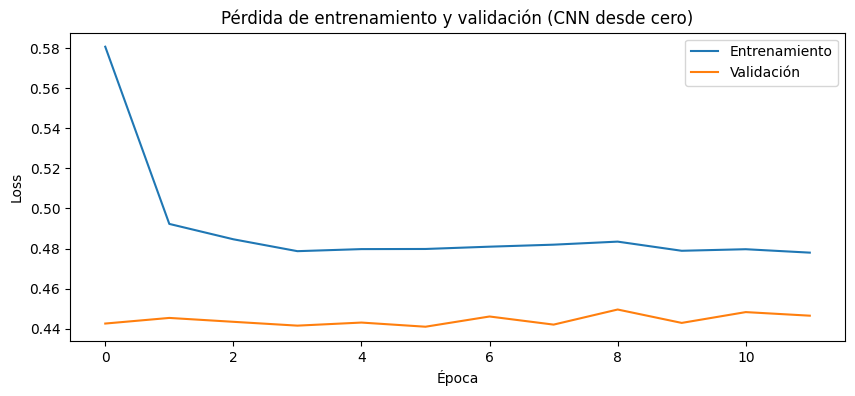

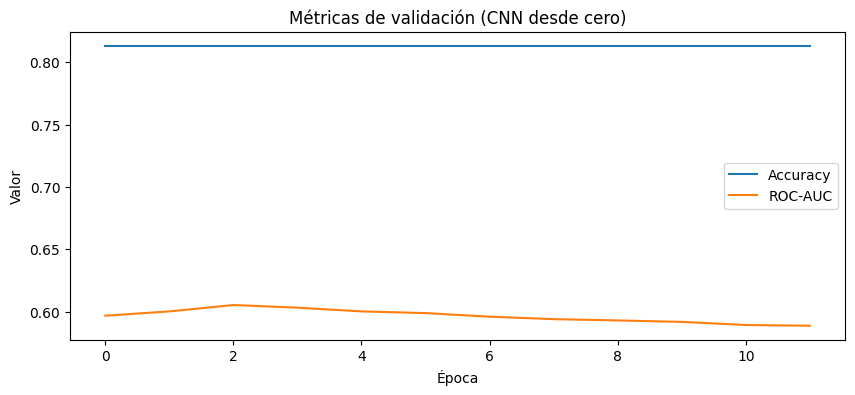

In [39]:
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["train_loss"],
    label="Entrenamiento"
)

plt.plot(
    history_scratch["val_loss"],
    label="Validación"
)

plt.title("Pérdida de entrenamiento y validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.show()


plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_acc"],
    label="Accuracy"
)

plt.plot(
    history_scratch["val_auc"],
    label="ROC-AUC"
)

plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()

plt.show()


##### 5.5 Evaluación en el conjunto de prueba

Finalmente, se evalúa el modelo utilizando el conjunto de prueba, que no fue utilizado durante el entrenamiento. Se calculan accuracy, ROC-AUC, precision, recall y F1-score mediante el reporte de clasificación.

También se presenta la matriz de confusión para observar los aciertos y errores de clasificación de cada clase.


Test accuracy: 0.8133
Test ROC-AUC: 0.5733

              precision    recall  f1-score   support

           0     0.8133    1.0000    0.8971       244
           1     0.0000    0.0000    0.0000        56

    accuracy                         0.8133       300
   macro avg     0.4067    0.5000    0.4485       300
weighted avg     0.6615    0.8133    0.7296       300

[[244   0]
 [ 56   0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


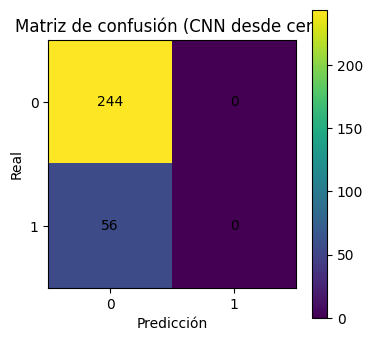

In [40]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(
    model_scratch,
    test_loader
)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print()

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

plt.figure(figsize=(4, 4))

plt.imshow(cm)

plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

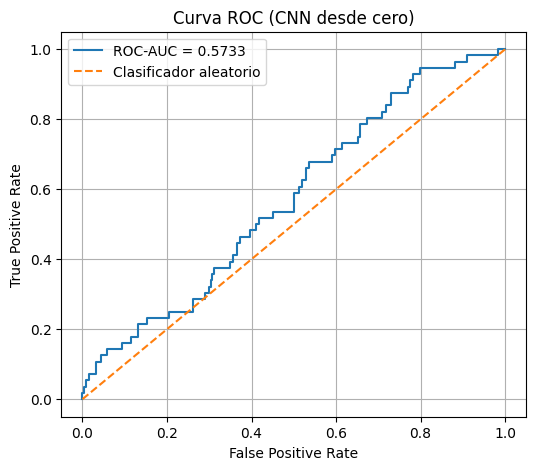

In [41]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC (CNN desde cero)")
plt.legend()
plt.grid()

plt.show()

### 5.6 Guardado del modelo

Se guarda el modelo entrenado para conservar los pesos obtenidos y poder utilizarlo posteriormente sin necesidad de repetir el entrenamiento.


In [42]:
torch.save(
    model_scratch.state_dict(),
    "cnn_scratch_dropout.pth"
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


## 6. Data Augmentation

El **Data Augmentation** consiste en aplicar transformaciones aleatorias a las imágenes de entrenamiento para generar variaciones de los datos disponibles.

En este caso, se utilizan pequeñas rotaciones y traslaciones para aumentar la variabilidad de las imágenes del dataset ISIC 2017. Estas transformaciones se aplican únicamente al conjunto de entrenamiento, mientras que los conjuntos de validación y prueba mantienen sus imágenes sin modificaciones.

El modelo utilizado continúa siendo la CNN entrenada desde cero de la sección anterior, incluyendo la capa **Dropout de 0.3** como estrategia de regularización.

Posteriormente se comparará el desempeño del modelo con y sin Data Augmentation mediante las métricas de accuracy y ROC-AUC.



### 6.1. Definición de las transformaciones

Se define una secuencia de transformaciones mediante `T.Compose()`.

`RandomRotation` aplica una rotación aleatoria de hasta 10 grados, mientras que `RandomAffine` permite realizar pequeñas traslaciones de la imagen.

Estas transformaciones se aplican únicamente al conjunto de entrenamiento aumentado. De esta manera, el modelo observa diferentes variaciones de las imágenes durante el entrenamiento sin modificar los conjuntos de validación y prueba.

In [43]:
transform_aug = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

train_dataset_aug = MelanomaDataset(
    train_df,
    image_dir,
    transform=transform_aug
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

### 6.2. Entrenamiento de la CNN con Data Augmentation

Se crea un nuevo modelo `model_aug` utilizando la misma arquitectura `SimpleCNN` empleada anteriormente.

La diferencia es que durante su entrenamiento se utiliza `train_loader_aug`, que proporciona imágenes con las transformaciones de Data Augmentation definidas anteriormente.

Se utiliza nuevamente `CrossEntropyLoss` y el optimizador Adam con una tasa de aprendizaje de `0.001`.

En este caso se realizan 6 épocas de entrenamiento y se almacenan la pérdida de entrenamiento, `Accuracy` y `ROC-AUC` de validación para analizar posteriormente el comportamiento del modelo.

In [44]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(), ##AQUI ESTOY
    lr=1e-3
)

epochs = 6

history_aug = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader
    )

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)


In [46]:
print("Resultados de entrenamiento:")
print()

for epoch in range(6):
    print(
        f"Época {epoch + 1} | "
        f"train_loss={history_aug['train_loss'][epoch]:.4f} | "
        f"val_acc={history_aug['val_acc'][epoch]:.4f} | "
        f"val_auc={history_aug['val_auc'][epoch]:.4f}"
    )

Resultados de entrenamiento:

Época 1 | train_loss=0.5749 | val_acc=0.8133 | val_auc=0.6096
Época 2 | train_loss=0.4984 | val_acc=0.8133 | val_auc=0.6099
Época 3 | train_loss=0.4900 | val_acc=0.8133 | val_auc=0.6105
Época 4 | train_loss=0.4873 | val_acc=0.8133 | val_auc=0.6108
Época 5 | train_loss=0.4830 | val_acc=0.8133 | val_auc=0.6104
Época 6 | train_loss=0.4822 | val_acc=0.8133 | val_auc=0.6101


In [47]:
import os

print("Archivos en /content:")
print(os.listdir("/content"))

Archivos en /content:
['.config', 'ISIC-2017_Training_Data.zip', 'ISIC_2017', 'cnn_scratch_dropout.pth', 'ISIC-2017_Training_Part3_GroundTruth.csv', 'sample_data']


In [48]:
torch.save(
    model_aug.state_dict(),
    "cnn_aug_dropout.pth"
)

print("Modelo con Data Augmentation guardado correctamente.")

Modelo con Data Augmentation guardado correctamente.


### 6.3. Comparación de resultados

Finalmente, se evalúa el modelo entrenado con Data Augmentation sobre el conjunto de prueba.

Se comparan la `Accuracy` y la `ROC-AUC` obtenidas por la CNN sin aumento de datos y por la CNN entrenada con aumento de datos.

Esta comparación permite observar si las transformaciones aplicadas durante el entrenamiento modifican el desempeño del modelo sobre imágenes que no fueron utilizadas para entrenarlo.

In [49]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8133 | test_auc=0.5733
Con augmentation  | test_acc=0.8133 | test_auc=0.5409


## 7. Transfer Learning

El **Transfer Learning** permite utilizar una red neuronal previamente entrenada sobre un conjunto de datos grande y adaptarla a una nueva tarea de clasificación.

En este caso se utiliza **ResNet18**, una arquitectura convolucional preentrenada con ImageNet. Debido a que el modelo original fue entrenado para clasificar múltiples categorías, se reemplaza su capa final por una nueva capa que permita clasificar las dos clases del dataset ISIC 2017:

* **Clase 0:** no melanoma.
* **Clase 1:** melanoma.

Primero se congelan los pesos de las capas convolucionales preentrenadas y se entrena únicamente la nueva capa de clasificación. Posteriormente, se descongela la última parte de la red para realizar un proceso de **fine-tuning**, permitiendo que el modelo adapte algunas de sus características al problema de clasificación de lesiones cutáneas.


In [50]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_tl = MelanomaDataset(
    train_df,
    image_dir,
    transform=transform_tl_train
)

val_dataset_tl = MelanomaDataset(
    val_df,
    image_dir,
    transform=transform_tl_eval
)

test_dataset_tl = MelanomaDataset(
    test_df,
    image_dir,
    transform=transform_tl_eval
)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

### 7.1. Construcción del modelo preentrenado

Se utiliza una **ResNet18 preentrenada con ImageNet**.

La capa final original de ResNet18 está diseñada para clasificar 1000 clases. Como nuestro problema solamente tiene dos clases, se reemplaza esta capa por una nueva capa `Linear` con dos salidas.

Inicialmente se congelan todos los parámetros del modelo y únicamente se permite entrenar la nueva capa de clasificación.

De esta manera, durante la primera etapa se aprovechan las características aprendidas previamente por ResNet18 y se adapta solamente el clasificador a las clases del presente trabajo.


In [51]:
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


### 7.2 Stage 1: entrenamiento de la capa de clasificación

En la primera etapa se mantienen congeladas las capas convolucionales de ResNet18 y se entrena únicamente la nueva capa de clasificación. Esto permite adaptar inicialmente el modelo al problema de clasificación binaria del dataset ISIC 2017.


In [52]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

epochs = 4

history_tl_stage1 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=0.5195 | val_acc=0.8167 | val_auc=0.5930
Stage1 Epoch 02 | train_loss=0.4765 | val_acc=0.8167 | val_auc=0.6493
Stage1 Epoch 03 | train_loss=0.4437 | val_acc=0.8167 | val_auc=0.6702
Stage1 Epoch 04 | train_loss=0.4278 | val_acc=0.8133 | val_auc=0.6879


### 7.3 Stage 2: Fine-tuning

Después de entrenar la capa de clasificación, se descongelan las capas correspondientes al último bloque convolucional (`layer4`) y la capa final (`fc`).

Se utiliza una tasa de aprendizaje menor para realizar ajustes más pequeños sobre los pesos preentrenados y adaptar las características de la red a las imágenes dermatoscópicas del dataset ISIC 2017.


In [53]:
for name, param in resnet.named_parameters():

    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [
    p for p in resnet.parameters()
    if p.requires_grad
]

len(trainable_params)

17

In [54]:
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs = 4

history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage2 Epoch 01 | train_loss=0.4173 | val_acc=0.8033 | val_auc=0.7220
Stage2 Epoch 02 | train_loss=0.2999 | val_acc=0.8133 | val_auc=0.7687
Stage2 Epoch 03 | train_loss=0.2474 | val_acc=0.8233 | val_auc=0.7919
Stage2 Epoch 04 | train_loss=0.1710 | val_acc=0.8367 | val_auc=0.7528


### 7.4. Evaluación en el conjunto de prueba

Una vez finalizado el fine-tuning, ResNet18 se evalúa utilizando el conjunto de prueba.

Se calculan `Accuracy` y `ROC-AUC`, además de un reporte de clasificación para las clases no melanoma y melanoma.

También se construye una matriz de confusión para observar las predicciones correctas e incorrectas de cada clase.

In [55]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet,
    test_loader_tl
)

print(
    f"Transfer learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        digits=4
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

print(cm_tl)


Transfer learning | test_acc=0.8233 | test_auc=0.7430

              precision    recall  f1-score   support

           0     0.8498    0.9508    0.8975       244
           1     0.5556    0.2679    0.3614        56

    accuracy                         0.8233       300
   macro avg     0.7027    0.6093    0.6295       300
weighted avg     0.7949    0.8233    0.7974       300

[[232  12]
 [ 41  15]]


### 7.5. Comparación global de los modelos


El modelo ResNet18 mediante Transfer Learning mostró una mejora progresiva durante el entrenamiento. En la primera etapa, donde únicamente se entrenó la capa de clasificación, el ROC-AUC de validación aumentó de 0.5930 a 0.6879. Posteriormente, al realizar el fine-tuning de las capas finales de la red, el mejor ROC-AUC de validación alcanzó 0.7919 en la tercera época.

En el conjunto de prueba, ResNet18 obtuvo una accuracy de **0.8233** y un ROC-AUC de **0.7430**. Sin embargo, el desempeño fue diferente entre las clases: para la clase 0 se obtuvo un recall de **0.9508**, mientras que para la clase 1 (melanoma) el recall fue de **0.2679**. Esto indica que el modelo clasificó correctamente una proporción alta de las lesiones de la clase 0, pero tuvo dificultades para identificar una parte importante de los casos de melanoma.

Por ello, la accuracy por sí sola no resulta suficiente para evaluar este problema, especialmente debido al desbalance entre las clases. El análisis conjunto de ROC-AUC, precision, recall, F1-score y matriz de confusión permite obtener



In [56]:
print("Resumen de resultados en test")

print(
    f"CNN desde cero (sin aug) | "
    f"acc={test_acc:.4f} | auc={test_auc:.4f}"
)

print(
    f"CNN desde cero (con aug) | "
    f"acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}"
)

print(
    f"Transfer learning (ResNet) | "
    f"acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}"
)

Resumen de resultados en test
CNN desde cero (sin aug) | acc=0.8133 | auc=0.5733
CNN desde cero (con aug) | acc=0.8133 | auc=0.5409
Transfer learning (ResNet) | acc=0.8233 | auc=0.7430


In [57]:
torch.save(
    resnet.state_dict(),
    "resnet18_isic2017.pth"
)

print("ResNet18 guardado correctamente.")

ResNet18 guardado correctamente.


## 8. Interpretabilidad básica: Grad-CAM

En aplicaciones relacionadas con imágenes médicas, además de obtener una predicción, es útil conocer qué regiones de la imagen influyeron en la decisión del modelo.

**Grad-CAM (Gradient-weighted Class Activation Mapping)** genera un mapa de activación que permite visualizar las regiones de la imagen que tuvieron mayor influencia en la predicción de una clase.

En esta sección se implementa una versión simplificada de Grad-CAM para el modelo **ResNet18** entrenado mediante Transfer Learning con el dataset ISIC 2017.

El mapa de calor se superpone sobre la imagen original para facilitar la interpretación visual de las regiones consideradas relevantes por el modelo.



In [58]:
import torch

def grad_cam(model, image_tensor, target_class=None):

    # Ponemos el modelo en modo evaluación para desactivar
    # comportamientos propios del entrenamiento.
    model.eval()

    # Enviamos la imagen al mismo dispositivo que utiliza el modelo.
    image_tensor = image_tensor.to(device)

    # Diccionarios donde almacenaremos:
    # - las activaciones producidas por la capa objetivo
    # - los gradientes asociados a esas activaciones
    activations = {}
    gradients = {}

    # Hook para guardar las activaciones generadas durante
    # la propagación hacia adelante (forward).
    def forward_hook(module, inp, out):
        activations["value"] = out

    # Hook para guardar los gradientes obtenidos durante
    # la propagación hacia atrás (backward).
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    # En ResNet18 utilizamos la última parte convolucional
    # de layer4 como capa objetivo para Grad-CAM.
    handle_fwd = model.layer4[-1].register_forward_hook(
        forward_hook
    )

    handle_bwd = model.layer4[-1].register_full_backward_hook(
        backward_hook
    )

    # Realizamos la predicción de la imagen.
    # Se agrega una dimensión al inicio porque el modelo
    # espera una entrada con formato [batch, canales, alto, ancho].
    logits = model(
        image_tensor.unsqueeze(0)
    )

    # Si no se especifica una clase, utilizamos la clase
    # que el modelo predijo con mayor puntuación.
    if target_class is None:
        target_class = int(
            torch.argmax(logits, dim=1).item()
        )

    # Seleccionamos el valor de salida correspondiente
    # a la clase que queremos analizar.
    score = logits[0, target_class]

    # Eliminamos los gradientes anteriores del modelo
    # antes de calcular los nuevos gradientes.
    model.zero_grad()

    # Calculamos los gradientes de la clase seleccionada
    # respecto a las activaciones de la capa objetivo.
    score.backward()

    # Recuperamos las activaciones y los gradientes almacenados
    # mediante los hooks.
    act = activations["value"][0]
    grad = gradients["value"][0]

    # Calculamos el promedio de los gradientes en las dimensiones
    # espaciales. Estos valores representan la importancia de
    # cada mapa de características para la clase analizada.
    weights = torch.mean(
        grad,
        dim=(1, 2)
    )

    # Combinamos los mapas de activación utilizando los pesos
    # calculados a partir de los gradientes.
    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    # Conservamos únicamente las activaciones positivas,
    # ya que representan regiones que contribuyen positivamente
    # a la predicción de la clase.
    cam = torch.relu(cam)

    # Normalizamos el mapa de activación para que sus valores
    # estén aproximadamente entre 0 y 1.
    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    # Eliminamos los hooks para evitar que permanezcan activos
    # después de terminar el cálculo de Grad-CAM.
    handle_fwd.remove()
    handle_bwd.remove()

    # Devolvemos el mapa de activación y la clase analizada.
    return (
        cam.detach().cpu().numpy(),
        target_class
    )





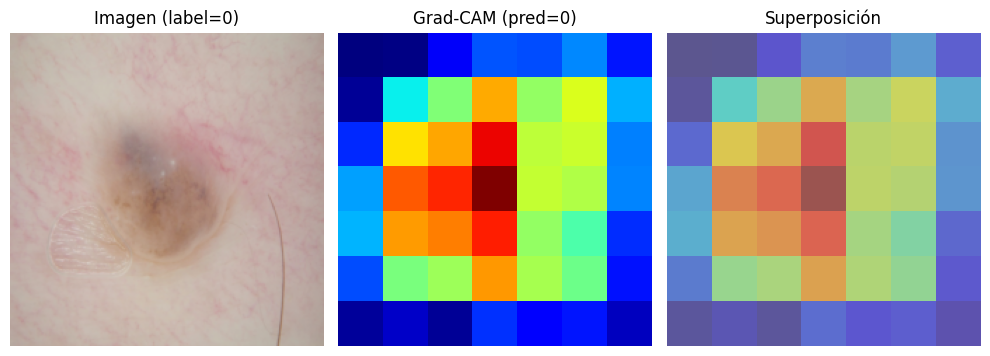

In [61]:
# Seleccionamos una imagen del conjunto de prueba.
idx = 0

# Obtenemos la imagen y su etiqueta real.
x, y = test_dataset_tl[idx]

# Calculamos el mapa Grad-CAM y obtenemos
# la clase predicha por el modelo.
cam, pred_class = grad_cam(
    resnet,
    x
)

# Convertimos la imagen desde el formato de PyTorch:
# [canales, alto, ancho]
# al formato utilizado por Matplotlib:
# [alto, ancho, canales].
img = x.permute(
    1, 2, 0
).cpu().numpy()

# Valores utilizados para deshacer la normalización
# aplicada anteriormente para ResNet18.
mean = np.array([
    0.485,
    0.456,
    0.406
])

std = np.array([
    0.229,
    0.224,
    0.225
])

# Desnormalizamos la imagen para poder visualizarla
# aproximadamente como la imagen original.
img = img * std + mean

# Limitamos los valores al intervalo [0, 1].
img = np.clip(
    img,
    0,
    1
)

plt.figure(figsize=(10, 4))

# --------------------------------------------------
# 1. Imagen original
# --------------------------------------------------
plt.subplot(1, 3, 1)

plt.imshow(img)

plt.title(
    f"Imagen (label={int(y.item())})"
)

plt.axis("off")


# --------------------------------------------------
# 2. Mapa de activación Grad-CAM
# --------------------------------------------------
plt.subplot(1, 3, 2)

# Las zonas con mayor intensidad representan
# regiones que tuvieron mayor influencia en la predicción.
plt.imshow(
    cam,
    cmap="jet"
)

plt.title(
    f"Grad-CAM (pred={pred_class})"
)

plt.axis("off")


# --------------------------------------------------
# 3. Superposición de Grad-CAM sobre la imagen
# --------------------------------------------------
plt.subplot(1, 3, 3)

# Mostramos primero la imagen original.
plt.imshow(img)

# Superponemos el mapa Grad-CAM con transparencia.
plt.imshow(
    cam,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Superposición"
)

plt.axis("off")

plt.tight_layout()

plt.show()



## 9. Buenas prácticas en clasificación de imágenes médicas

En problemas de clasificación de imágenes médicas, como la detección de melanoma a partir de imágenes dermatoscópicas, es importante considerar que el modelo de inteligencia artificial constituye una **herramienta de apoyo** y no un sustituto de la evaluación de un profesional de la salud.

Además de la exactitud, se deben analizar métricas como **precision, recall, F1-score y ROC-AUC**, ya que una sola métrica puede ocultar errores importantes, especialmente cuando las clases no están equilibradas.

En este dataset existe un mayor número de imágenes correspondientes a lesiones sin melanoma que de imágenes con melanoma. Por ello, resulta importante observar el comportamiento del modelo en ambas clases y revisar la **matriz de confusión**.

También es importante utilizar conjuntos de entrenamiento, validación y prueba separados. El conjunto de prueba debe mantenerse independiente durante el desarrollo del modelo para obtener una evaluación más objetiva de su desempeño.

Finalmente, técnicas de interpretabilidad como **Grad-CAM** permiten visualizar qué regiones de la imagen influyeron en la predicción. Sin embargo, estas visualizaciones deben interpretarse con precaución y no deben considerarse por sí solas como evidencia de una decisión clínica.

### Consideraciones principales

* Separar correctamente los conjuntos de entrenamiento, validación y prueba.
* Considerar el desbalance entre las clases.
* Analizar varias métricas de evaluación y no únicamente accuracy.
* Revisar la matriz de confusión para identificar errores de clasificación.
* Utilizar técnicas de interpretabilidad como Grad-CAM como apoyo para analizar el comportamiento del modelo.
* Recordar que el modelo desarrollado tiene fines académicos y experimentales y no constituye una herramienta de diagnóstico médico.



In [ ]:
print("Resumen final de modelos")
print("=" * 50)

print(
    f"CNN desde cero        | "
    f"Accuracy={test_acc:.4f} | "
    f"ROC-AUC={test_auc:.4f}"
)

print(
    f"CNN + Augmentation    | "
    f"Accuracy={test_acc_aug:.4f} | "
    f"ROC-AUC={test_auc_aug:.4f}"
)

print(
    f"ResNet18 + Transfer   | "
    f"Accuracy={test_acc_tl:.4f} | "
    f"ROC-AUC={test_auc_tl:.4f}"
)

## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]




Una vez finalizado el entrenamiento, es importante guardar los modelos para poder utilizarlos posteriormente sin tener que repetir todo el proceso de entrenamiento.

En este trabajo se guardan los tres modelos desarrollados:

* **CNN desde cero con Dropout**
* **CNN desde cero con Dropout y Data Augmentation**
* **ResNet18 mediante Transfer Learning**

Se utiliza `state_dict()` para almacenar los parámetros aprendidos por cada modelo.


In [ ]:
# Guardamos los parámetros aprendidos por la CNN
# entrenada desde cero.
torch.save(
    model_scratch.state_dict(),
    "cnn_scratch_dropout.pth"
)

print("CNN desde cero guardada correctamente.")

In [ ]:
# Guardamos los parámetros aprendidos por la CNN
# entrenada utilizando Data Augmentation.
torch.save(
    model_aug.state_dict(),
    "cnn_aug_dropout.pth"
)

print("CNN con Data Augmentation guardada correctamente.")

In [ ]:
# Guardamos los parámetros aprendidos por ResNet18
# después del proceso de Transfer Learning y fine-tuning.
torch.save(
    resnet.state_dict(),
    "resnet18_isic2017.pth"
)

print("ResNet18 guardado correctamente.")

In [ ]:
import os

print("Archivos de modelos guardados:")

for file in os.listdir("."):
    if file.endswith(".pth"):
        print("-", file)